In [1]:
import scipy.interpolate as interp 
try:
    import cupy as xp
except (ImportError, ModuleNotFoundError) as e:
    import numpy as xp
from scipy.signal import windows 

from Triangle.Constants import *
from Triangle.FFTTools import *
from Triangle.Noise import *
from Triangle.Orbit import *
from Triangle.Data import *
from Triangle.TDI import *
from Triangle.GW import *
from Triangle.TDIFly import * 

import matplotlib
matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['font.family'] = 'serif'
import matplotlib.pyplot as plt

PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


has cupy


has cupy


## Settings 

In [3]:
orbit = Orbit(OrbitDir="../OrbitData/MicroSateOrbitEclipticTCB")
Tobs = YEAR
dt = 10.0
tcb_times = np.arange(int(Tobs / dt)) * dt

## Initialize response models 

### TDI-on-the-fly

In [4]:
X2_strings = TDIFly.X2_strings
Y2_strings = TDIStringManipulation.TDIStringCyc(X2_strings)
Z2_strings = TDIStringManipulation.TDIStringCyc(Y2_strings)

gb_tdifly_generator = TDIFlyGB(
    orbit=orbit, 
    Pstring_list=[X2_strings, Y2_strings, Z2_strings], 
    tcb_times=tcb_times, 
    # Nsparse=1024, 
    Nsparse=512,
    # Nsparse=256,
    # drop_points=100, 
    use_gpu=False, 
)



### original polarization-based TDI response 

In [5]:
gb_waveform_generator = GB_Injection(use_gpu=False)
gb_response_generator = FastMichelsonTDIResponse(
    orbit=orbit, 
    tcb_times=tcb_times, 
    use_gpu=False, 
    drop_points=100, 
    # interp_method="linear", 
    # interp_method="Akima", 
    interp_method="Spline3",
)

## Source population 

In [6]:
# GB_catalogue = np.load("/Users/taijidatacenter/workspace/Triangle-GB/Examples/BrightGBParams.npy")
GB_catalogue = np.load("../../BrightGBParams.npy")
GB_parameters = dict(
    A=GB_catalogue[:, 0], 
    f0=GB_catalogue[:, 1], 
    fdot0=GB_catalogue[:, 2], 
    inclination=GB_catalogue[:, 5], 
    phase0=GB_catalogue[:, 4], 
    longitude=GB_catalogue[:, 6], 
    latitude=GB_catalogue[:, 7], 
    psi=GB_catalogue[:, 8], 
)

N_GB_total = GB_catalogue.shape[0]
N_GB_total

18984

## Compare one selected source 

In [7]:
test_GB_idx = int(np.random.uniform(0, N_GB_total))
test_GB_parameters = dict()
for k, v in GB_parameters.items():
    test_GB_parameters[k] = v[test_GB_idx]
test_GB_idx, test_GB_parameters

(2479,
 {'A': 3.8237139213297717e-23,
  'f0': 0.003921245469400406,
  'fdot0': 1.9041180001284327e-16,
  'inclination': 3.027748580804567,
  'phase0': 0.524250270996823,
  'longitude': 4.671166085726754,
  'latitude': -0.06985108458012931,
  'psi': 2.2067667297842117})

### time-domain simulation

In [8]:
mich_aet_td = gb_response_generator(
    parameters=test_GB_parameters, 
    waveform_generator=gb_waveform_generator, 
    optimal_combination=True, 
    )

mich_a = np.fft.rfft(mich_aet_td[0]) * dt 
mich_e = np.fft.rfft(mich_aet_td[1]) * dt 
freqs = np.fft.rfftfreq(n=mich_aet_td.shape[-1], d=dt)

cut_freq_range = 5e-5 
# cut_freq_range = 5e-6
cut_freq_idx = np.where(np.abs(freqs-test_GB_parameters["f0"])<cut_freq_range)[0]
freqs = freqs[cut_freq_idx]
mich_ae = np.array([
    mich_a[cut_freq_idx], 
    mich_e[cut_freq_idx], 
])

mich_ae.shape # (Nchannel, Nfreq)

(2, 3156)

### frequency-domain model 

In [9]:
# test_GB_parameters_vec = dict()
# for k, v in test_GB_parameters.items():
#     test_GB_parameters_vec[k] = v * np.ones(1)

fly_xyz = gb_tdifly_generator(
    parameters=test_GB_parameters, 
    domain="frequency"
    )
fly_aet = AETfromXYZ(fly_xyz[0], fly_xyz[1], fly_xyz[2])
fly_ae_valid = np.array([fly_aet[0], fly_aet[1]])


fly_ae = gb_tdifly_generator.fill_fftseries(
    data=fly_ae_valid, 
    start_idx=gb_tdifly_generator.start_idx, 
    StartBound=cut_freq_idx[0], 
    EndBound=cut_freq_idx[-1],
)

# fly_ae = gb_tdifly_generator.fill_fftseries_loop(
#     data=fly_ae_valid, 
#     start_idx=gb_tdifly_generator.start_idx, 
#     StartBound=cut_freq_idx[0], 
#     EndBound=cut_freq_idx[-1],
# )

fly_ae.shape # (Nchannel, Nevent, Nfreq)

(2, 1, 3156)

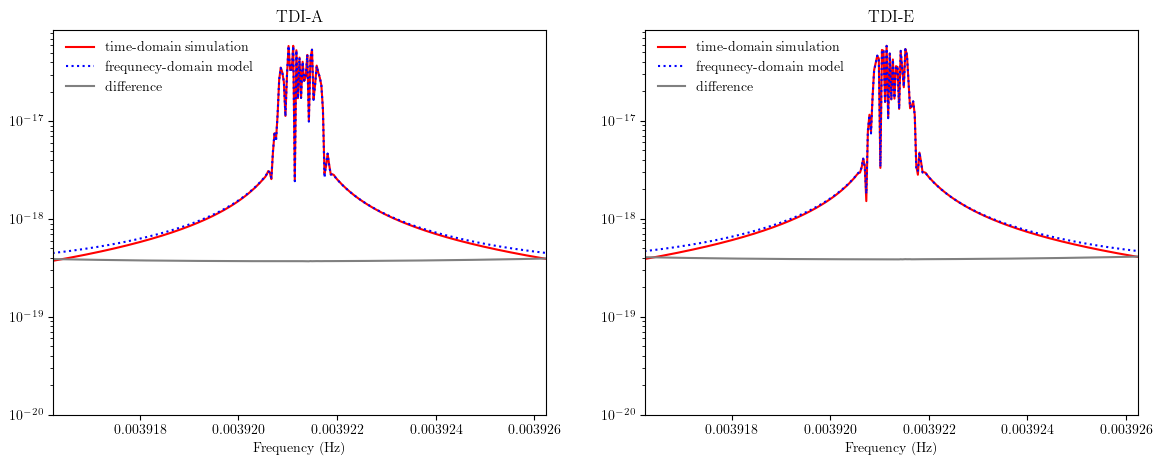

In [10]:
plt.figure(figsize=(14, 5))
for ichannel, nchannel in enumerate(["A", "E"]):
    plt.subplot(121+ichannel)
    plt.semilogy(freqs, np.abs(mich_ae[ichannel]), color="r", label="time-domain simulation")
    plt.semilogy(freqs, np.abs(fly_ae[ichannel][0]), linestyle=":", color="b", label="frequnecy-domain model")
    plt.semilogy(freqs, np.abs(fly_ae[ichannel][0] - mich_ae[ichannel]), linestyle="-", color="grey", label="difference")
    plt.legend(frameon=False, loc="upper left")
    plt.xlim(test_GB_parameters["f0"]-5e-6, test_GB_parameters["f0"]+5e-6)
    plt.ylim(1e-20,)
    plt.xlabel("Frequency (Hz)")
    plt.title("TDI-"+nchannel)

In [11]:
print("template SNR:", gb_tdifly_generator.SNR(fly_ae, test_GB_parameters["f0"], Tobs))
print("data SNR:", gb_tdifly_generator.SNR(mich_ae[:, xp.newaxis, :], test_GB_parameters["f0"], Tobs))
print("residual SNR:", gb_tdifly_generator.SNR(fly_ae - mich_ae[:, xp.newaxis,:], test_GB_parameters["f0"], Tobs))
print("mismatch:", gb_tdifly_generator.mismatch(h1=mich_ae, h2=fly_ae))
print("mismatch threshold:", 2. * 8. / gb_tdifly_generator.SNR(fly_ae, test_GB_parameters["f0"], Tobs) ** 2)

template SNR: [77.99328876]
data SNR: [77.98360681]
residual SNR: [4.28995343]
mismatch: [0.00151291]
mismatch threshold: [0.0026303]


## Test F-stat and likelihood 

In [12]:
intrinsic_parameters = dict() 
for key in TDIFlyGB.intrinsic_parameter_names: 
    intrinsic_parameters[key] = test_GB_parameters[key]

In [13]:
Ntest = 101
test_scale = 1e-8
test_params = test_GB_parameters["f0"] + np.linspace(-test_scale, test_scale, Ntest)
test_all_params = dict()
test_int_params = dict() 
for k, v in test_GB_parameters.items():
    test_all_params[k] = np.ones(Ntest) * v 
    if k in ["f0", "fdot0", "longitude", "latitude"]: 
        test_int_params[k] = np.ones(Ntest) * v 
    if k == "f0": 
        test_all_params[k] = test_params 
        test_int_params[k] = test_params

FLL = gb_tdifly_generator.Fstatistics(
    data=mich_ae, 
    intrinsic_parameters=test_int_params, 
    StartBound=cut_freq_idx[0], 
    EndBound=cut_freq_idx[-1], 
    Tobs=Tobs, 
    S=gb_tdifly_generator.PSD_A2(f=test_GB_parameters["f0"])
)

LL = gb_tdifly_generator.Likelihood(
    data=mich_ae, 
    parameters=test_all_params, 
    StartBound=cut_freq_idx[0], 
    EndBound=cut_freq_idx[-1], 
    Tobs=Tobs, 
    S=gb_tdifly_generator.PSD_A2(f=test_GB_parameters["f0"])
)

FLL.shape, LL.shape 

((101,), (101,))

Text(0, 0.5, '$\\Delta {\\rm ln}\\mathcal L$')

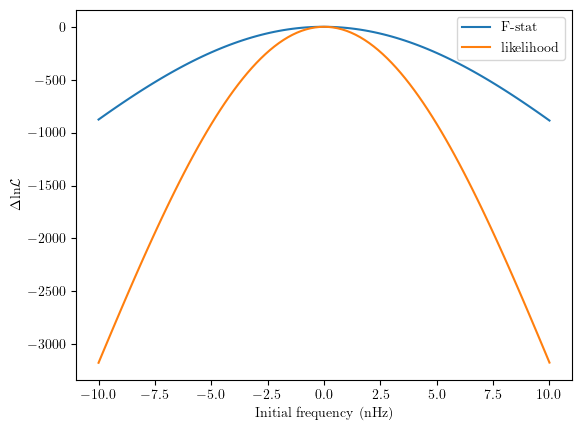

In [14]:
plt.plot((test_params - test_GB_parameters["f0"])*1e9, (FLL - np.max(FLL)), label="F-stat")
plt.plot((test_params - test_GB_parameters["f0"])*1e9, LL - np.max(LL), label="likelihood")
plt.legend()
plt.xlabel("Initial frequency (nHz)")
plt.ylabel(r'$\Delta {\rm ln}\mathcal L$')

In [15]:
Ntest = 101
test_scale = 1e-16
test_params = test_GB_parameters["fdot0"] + np.linspace(-test_scale, test_scale, Ntest)
test_all_params = dict()
test_int_params = dict() 
for k, v in test_GB_parameters.items():
    test_all_params[k] = np.ones(Ntest) * v 
    if k in ["f0", "fdot0", "longitude", "latitude"]: 
        test_int_params[k] = np.ones(Ntest) * v 
    if k == "fdot0": 
        test_all_params[k] = test_params 
        test_int_params[k] = test_params

FLL = gb_tdifly_generator.Fstatistics(
    data=mich_ae, 
    intrinsic_parameters=test_int_params, 
    StartBound=cut_freq_idx[0], 
    EndBound=cut_freq_idx[-1], 
    Tobs=Tobs, 
    S=gb_tdifly_generator.PSD_A2(f=test_GB_parameters["f0"])
)

LL = gb_tdifly_generator.Likelihood(
    data=mich_ae, 
    parameters=test_all_params, 
    StartBound=cut_freq_idx[0], 
    EndBound=cut_freq_idx[-1], 
    Tobs=Tobs, 
    S=gb_tdifly_generator.PSD_A2(f=test_GB_parameters["f0"])
)

FLL.shape, LL.shape 

((101,), (101,))

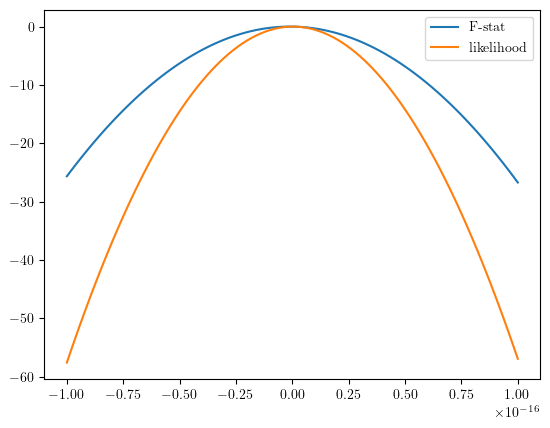

In [16]:
plt.plot((test_params - test_GB_parameters["fdot0"]), (FLL - np.max(FLL)), label="F-stat")
plt.plot((test_params - test_GB_parameters["fdot0"]), LL - np.max(LL), label="likelihood")
plt.legend()

In [17]:
Ntest = 101
test_scale = 1e-1
test_params = test_GB_parameters["longitude"] + np.linspace(-test_scale, test_scale, Ntest)
test_all_params = dict()
test_int_params = dict() 
for k, v in test_GB_parameters.items():
    test_all_params[k] = np.ones(Ntest) * v 
    if k in ["f0", "fdot0", "longitude", "latitude"]: 
        test_int_params[k] = np.ones(Ntest) * v 
    if k == "longitude": 
        test_all_params[k] = test_params 
        test_int_params[k] = test_params

FLL = gb_tdifly_generator.Fstatistics(
    data=mich_ae, 
    intrinsic_parameters=test_int_params, 
    StartBound=cut_freq_idx[0], 
    EndBound=cut_freq_idx[-1], 
    Tobs=Tobs, 
    S=gb_tdifly_generator.PSD_A2(f=test_GB_parameters["f0"])
)

LL = gb_tdifly_generator.Likelihood(
    data=mich_ae, 
    parameters=test_all_params, 
    StartBound=cut_freq_idx[0], 
    EndBound=cut_freq_idx[-1], 
    Tobs=Tobs, 
    S=gb_tdifly_generator.PSD_A2(f=test_GB_parameters["f0"])
)

FLL.shape, LL.shape 

((101,), (101,))

Text(0, 0.5, '$\\Delta {\\rm ln}\\mathcal L$')

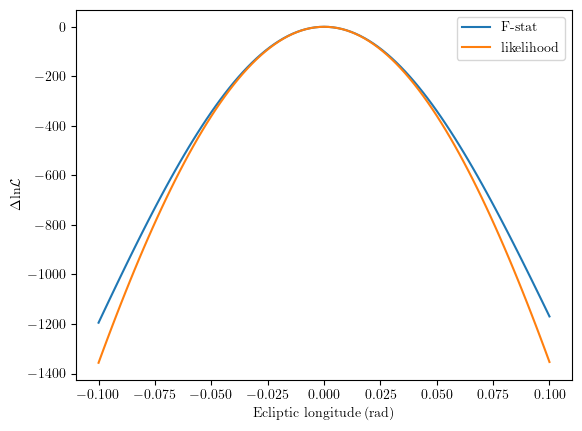

In [18]:
plt.plot((test_params - test_GB_parameters["longitude"]), (FLL - np.max(FLL)), label="F-stat")
plt.plot((test_params - test_GB_parameters["longitude"]), LL - np.max(LL), label="likelihood")
plt.legend()
plt.xlabel("Ecliptic longitude (rad)")
plt.ylabel(r'$\Delta {\rm ln}\mathcal L$')

In [19]:
Ntest = 101
test_scale = 1e-1
test_params = test_GB_parameters["latitude"] + np.linspace(-test_scale, test_scale, Ntest)
test_all_params = dict()
test_int_params = dict() 
for k, v in test_GB_parameters.items():
    test_all_params[k] = np.ones(Ntest) * v 
    if k in ["f0", "fdot0", "longitude", "latitude"]: 
        test_int_params[k] = np.ones(Ntest) * v 
    if k == "latitude": 
        test_all_params[k] = test_params 
        test_int_params[k] = test_params

FLL = gb_tdifly_generator.Fstatistics(
    data=mich_ae, 
    intrinsic_parameters=test_int_params, 
    StartBound=cut_freq_idx[0], 
    EndBound=cut_freq_idx[-1], 
    Tobs=Tobs, 
    S=gb_tdifly_generator.PSD_A2(f=test_GB_parameters["f0"])
)

LL = gb_tdifly_generator.Likelihood(
    data=mich_ae, 
    parameters=test_all_params, 
    StartBound=cut_freq_idx[0], 
    EndBound=cut_freq_idx[-1], 
    Tobs=Tobs, 
    S=gb_tdifly_generator.PSD_A2(f=test_GB_parameters["f0"])
)

FLL.shape, LL.shape 

((101,), (101,))

Text(0, 0.5, '$\\Delta {\\rm ln}\\mathcal L$')

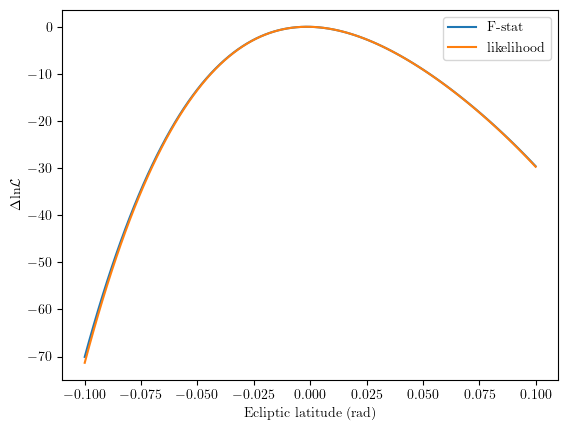

In [20]:
plt.plot((test_params - test_GB_parameters["latitude"]), (FLL - np.max(FLL)), label="F-stat")
plt.plot((test_params - test_GB_parameters["latitude"]), LL - np.max(LL), label="likelihood")
plt.legend()
plt.xlabel("Ecliptic latitude (rad)")
plt.ylabel(r'$\Delta {\rm ln}\mathcal L$')

## Test parameter and waveform recovery

In [21]:
searched_a = gb_tdifly_generator.Fstatistics(
    data=mich_ae, 
    intrinsic_parameters=intrinsic_parameters, 
    StartBound=cut_freq_idx[0], 
    EndBound=cut_freq_idx[-1], 
    Tobs=Tobs, 
    S=gb_tdifly_generator.PSD_A2(f=test_GB_parameters["f0"]), 
    return_a=True, 
)
searched_ext_params = gb_tdifly_generator.a_to_extrinsic(searched_a)

print("name | recovered value | true value | difference")
for k, v in searched_ext_params.items():
    print(k, v, test_GB_parameters[k], v - test_GB_parameters[k])

name | recovered value | true value | difference
A 3.9056566693858246e-23 3.8237139213297717e-23 8.194274805605287e-25
inclination 2.8996656267487095 3.027748580804567 -0.12808295405585746
psi 2.1471875723649916 2.2067667297842117 -0.05957915741922015
phase0 0.40650988008075306 0.524250270996823 -0.11774039091606991


In [22]:
searched_wf = gb_tdifly_generator.Fstatistics(
    data=mich_ae, 
    intrinsic_parameters=intrinsic_parameters, 
    StartBound=cut_freq_idx[0], 
    EndBound=cut_freq_idx[-1], 
    Tobs=Tobs, 
    S=gb_tdifly_generator.PSD_A2(f=test_GB_parameters["f0"]), 
    return_recovered_wave=True, 
)

searched_wf.shape 

(2, 1, 3156)

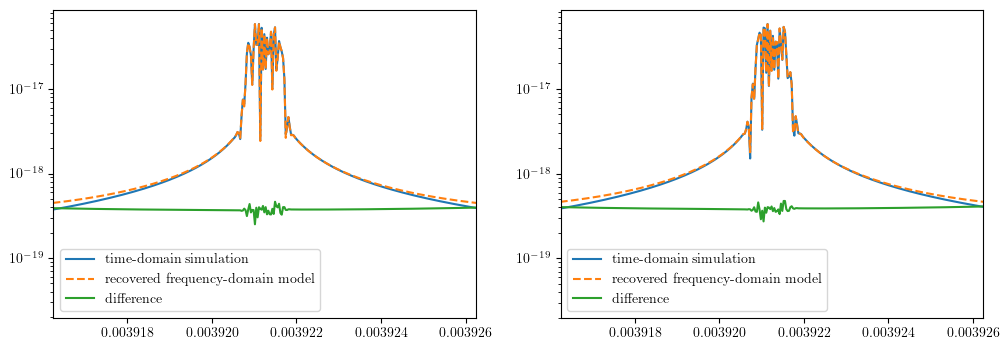

In [23]:
plt.figure(figsize=(12,4))
for i in range(2):
    plt.subplot(121+i)
    plt.semilogy(freqs, np.abs(mich_ae[i, :]), label="time-domain simulation")
    plt.semilogy(freqs, np.abs(searched_wf[i, 0, :]), linestyle="--", label="recovered frequency-domain model")
    plt.semilogy(freqs, np.abs(searched_wf[i, 0, :] - mich_ae[i, :]), linestyle="-", label="difference")
    plt.xlim(test_GB_parameters["f0"]-5e-6, test_GB_parameters["f0"]+5e-6)
    plt.legend(loc="lower left")

## Test GB blind search 

In [24]:
intrinsic_param_priors = np.array([
    [intrinsic_parameters["f0"] - 3e-6, intrinsic_parameters["f0"] + 3e-6], 
    [intrinsic_parameters["fdot0"] / 2., intrinsic_parameters["fdot0"] * 2.], 
    [0, TWOPI], 
    [-1., 1.]
])

In [25]:
from scipy.optimize import differential_evolution

def cost_function(norm_int_params):
    """   
        norm_int_params: shape (Nparams, Nevent), normalized to (0, 1)
    """
    int_params = norm_int_params.transpose() * (intrinsic_param_priors[:, 1] - intrinsic_param_priors[:, 0]) + intrinsic_param_priors[:, 0] # (Nevent, Nparams)
    params_in = TDIFlyGB.IntParamArr2Dict(int_params.transpose()) # (Nparams, Nevent) -> dictionary, each item (Nevent)
    return -gb_tdifly_generator.Fstatistics(
        data=mich_ae, 
        intrinsic_parameters=params_in, 
        StartBound=cut_freq_idx[0], 
        EndBound=cut_freq_idx[-1], 
        Tobs=Tobs, 
        S=gb_tdifly_generator.PSD_A2(f=test_GB_parameters["f0"]), 
        ) # (Nevent)

n_dim_int = 4
lower_bounds = np.zeros(n_dim_int) 
upper_bounds = np.ones(n_dim_int) 
bounds = np.array([lower_bounds, upper_bounds]).T # (Nparams, 2)

DE_result = differential_evolution(
    func=cost_function,
    bounds=bounds,
    x0=None,
    strategy='best1exp',
    # strategy='rand1bin',
    maxiter=5000,
    popsize=5*n_dim_int, 
    tol=1e-6,
    atol=1e-8,
    mutation=(0.4, 0.95),
    recombination=0.7,
    disp=False,
    polish=False,
    vectorized=True,
)

print(DE_result)

/home/ps/miniconda3/envs/tdc/lib/python3.9/site-packages/scipy/optimize/_differentialevolution.py:487: UserWarning: differential_evolution: the 'vectorized' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


             message: Optimization terminated successfully.
             success: True
                 fun: -3031.5693569853365
                   x: [ 5.000e-01  3.627e-01  7.435e-01  4.654e-01]
                 nit: 68
                nfev: 69
          population: [[ 5.000e-01  3.627e-01  7.435e-01  4.654e-01]
                       [ 5.000e-01  3.690e-01  7.435e-01  4.656e-01]
                       ...
                       [ 5.000e-01  3.684e-01  7.435e-01  4.652e-01]
                       [ 5.000e-01  3.620e-01  7.435e-01  4.655e-01]]
 population_energies: [-3.032e+03 -3.032e+03 ... -3.032e+03 -3.032e+03]


In [26]:
searched_int_params = TDIFlyGB.IntParamArr2Dict(DE_result.x * (intrinsic_param_priors[:, 1] - intrinsic_param_priors[:, 0]) + intrinsic_param_priors[:, 0])
searched_a = gb_tdifly_generator.Fstatistics(
    data=mich_ae, 
    intrinsic_parameters=searched_int_params, 
    StartBound=cut_freq_idx[0], 
    EndBound=cut_freq_idx[-1], 
    Tobs=Tobs, 
    S=gb_tdifly_generator.PSD_A2(f=test_GB_parameters["f0"]), 
    return_a=True, 
)
searched_ext_params = TDIFlyGB.a_to_extrinsic(searched_a)

searched_params = dict(searched_int_params, **searched_ext_params)

print("parameter name | parameter truths | difference")
for k, v in searched_params.items(): 
    print(k, test_GB_parameters[k], np.abs(v-test_GB_parameters[k]))

parameter name | parameter truths | difference
f0 0.003921245469400406 1.8821550568093315e-10
fdot0 1.9041180001284327e-16 8.382063306388136e-18
longitude 4.671166085726754 0.00029841122003748666
latitude -0.06985108458012931 0.000503189005933713
A 3.8237139213297717e-23 4.945029633650755e-25
inclination 3.027748580804567 0.0907738127818809
psi 2.2067667297842117 0.13930570541670662
phase0 0.524250270996823 0.2674955185634572


In [27]:
searched_wf = gb_tdifly_generator.Fstatistics(
    data=mich_ae, 
    intrinsic_parameters=searched_int_params, 
    StartBound=cut_freq_idx[0], 
    EndBound=cut_freq_idx[-1], 
    Tobs=Tobs, 
    S=gb_tdifly_generator.PSD_A2(f=test_GB_parameters["f0"]), 
    return_recovered_wave=True, 
)

searched_wf.shape

(2, 1, 3156)

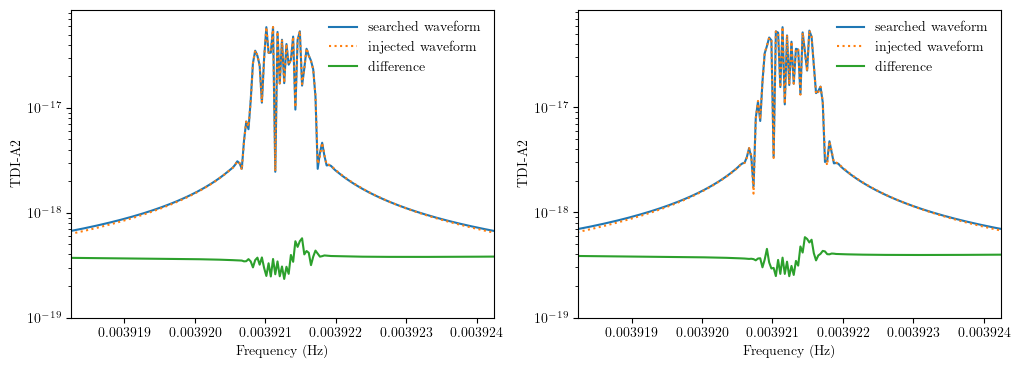

In [28]:
plt.figure(figsize=(12,4))
for i in range(2):
    plt.subplot(121+i)
    plt.semilogy(freqs, np.abs(searched_wf[i][0]), label="searched waveform")
    plt.semilogy(freqs, np.abs(mich_ae[i]), linestyle=":", label="injected waveform")
    plt.semilogy(freqs, np.abs(searched_wf[i][0] - mich_ae[i]), label="difference")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("TDI-A2")
    plt.legend(loc="upper right", frameon=False)
    plt.xlim(intrinsic_param_priors[0][0], intrinsic_param_priors[0][1])
    plt.ylim(1e-19,)